# Продвинутое домашнее задание: Доменная адаптация энкодерной модели для семантического поиска

В рамках этого домашнего задания вы пройдете полный цикл адаптации предобученной англоязычной энкодерной модели `sentence-transformers/all-MiniLM-L6-v2` (обратите внимание: модель обучалась на английских данных, что делает задачу адаптации к русскому языку особенно показательной) для работы с русскоязычными текстами. Ваша цель - улучшить качество семантического поиска и визуально оценить изменения в пространстве эмбеддингов.

**Важное предупреждение:** Доменная адаптация - это сложный процесс, требующий тщательного подбора гиперпараметров и качественных данных. В рамках выполнения данного ДЗ в образовательных целях, скорее всего, вы получите лишь незначительное улучшение метрик поиска. Это абсолютно нормально. Главная цель - освоить методологию и пайплайн дообучения.

In [1]:
!pip install sentence-transformers datasets faiss-cpu umap-learn matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 62.7 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import umap
from tqdm.auto import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

/tmp/ipykernel_1475/1064979242.py:10: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


## Часть 1. Визуализация пространства эмбеддингов до адаптации (20 баллов)

Перед тем как что либо улучшать, необходимо понять, с чем мы имеем дело. Мы визуализируем эмбеддинги коротких текстов, чтобы увидеть, насколько хорошо базовая модель разделяет их по смыслу.

**Задание:**
1. Загрузите датасет `ai-forever/headline-classification` (сплит `test`, возьмите первые 1000 примеров: `split="test[:1000]"`). Датасет содержит колонки `text` (заголовок новости на русском языке, строка), `label` (номер класса, число) и `label_text` (название тематики, строка: спорт, политика, экономика и т.д.). Для получения эмбеддингов используйте колонку `text`, для раскраски точек на графике - колонку `label_text`.
2. Инициализируйте базовую модель `sentence-transformers/all-MiniLM-L6-v2`.
3. Получите эмбеддинги для текстов из датасета.
4. Напишите функцию для понижения размерности эмбеддингов до 2D с использованием алгоритма UMAP.
5. Постройте scatter plot, раскрасив точки в соответствии с метками классов.

**Подсказки:**
* Обязательно зафиксируйте `random_state` в UMAP для воспроизводимости.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/36000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/12000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12000 [00:00<?, ? examples/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


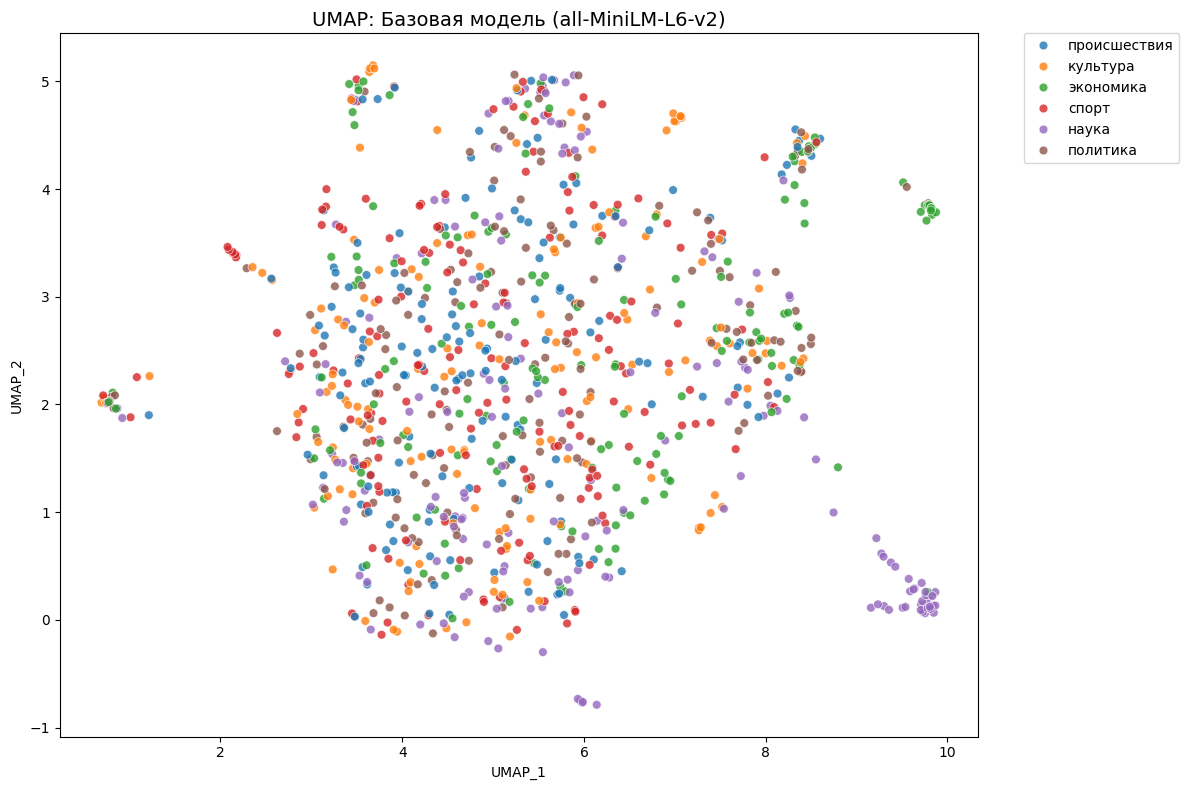

In [4]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"
base_model = SentenceTransformer(model_name)

# Загрузка датасета для визуализации
vis_dataset = load_dataset("ai-forever/headline-classification", split="test[:1000]")
vis_texts = vis_dataset["text"]
vis_labels = vis_dataset["label_text"]

# Получение эмбеддингов базовой моделью
with torch.no_grad():
    base_embeddings = base_model.encode(
        vis_texts,
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True
    )

def plot_embeddings(embeddings, labels, title):
    # Понижение размерности до 2D с зафиксированным random_state
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=SEED)
    embeddings_2d = reducer.fit_transform(embeddings)

    # Создание датафрейма для отрисовки
    df_plot = pd.DataFrame({
        'UMAP_1': embeddings_2d[:, 0],
        'UMAP_2': embeddings_2d[:, 1],
        'Category': labels
    })

    # Построение графика
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_plot,
        x='UMAP_1',
        y='UMAP_2',
        hue='Category',
        palette='tab10',
        alpha=0.8,
        s=40
    )
    plt.title(title, fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

# Визуализация
plot_embeddings(base_embeddings, vis_labels, "UMAP: Базовая модель (all-MiniLM-L6-v2)")

## Часть 2. Оценка базового качества поиска (25 баллов)

Теперь замерим метрики семантического поиска до доменной адаптации.

**Задание:**
1. Загрузите датасет `ai-forever/rubq-retrieval`. Этот датасет состоит из трех отдельных подмножеств, которые нужно загрузить отдельно:
   * Вопросы: подмножество (config) `queries`, сплит `queries`. Содержит колонки `_id` (строка) и `text` (строка).
   * База знаний: подмножество (config) `corpus`, сплит `corpus`. Содержит колонки `_id` (строка), `title` (строка) и `text` (строка).
   * Разметка релевантности (qrels): подмножество (config) `default`, сплит `test`. Содержит колонки `query-id` (строка), `corpus-id` (строка) и `score` (число).
2. Напишите функцию `evaluate_retrieval`, которая принимает на вход модель, вопросы (`queries`), базу знаний (`corpus`) и разметку релевантности (`qrels`), и возвращает метрики Recall@5 и Recall@10.
3. Для ускорения поиска реализуйте индекс на основе `faiss.IndexFlatIP`.
4. Замерьте и зафиксируйте базовое качество поиска.

**Подсказки и рекомендации по оценке:**
* Поскольку мы используем `faiss.IndexFlatIP` (поиск по скалярному произведению), векторы перед добавлением в индекс необходимо L2-нормализовать. Укажите `normalize_embeddings=True` при вызове метода `encode`.
* **Как считать Recall@K:**
  1. Для каждого вопроса (колонка `text` из `queries`) получите топ-K ближайших документов из базы знаний (колонка `text` из `corpus`) с помощью `faiss.Index.search`.
  2. Для этого же вопроса найдите все правильные (релевантные) документы в таблице `qrels` (строки, где колонка `query-id` совпадает с `_id` вопроса, а колонка `corpus-id` содержит ID правильных документов). Обратите внимание: у многих вопросов правильных документов несколько.
  3. Вычислите Recall@K для текущего вопроса по формуле: (количество правильных документов, попавших в ваш топ-K) / (общее количество правильных документов для этого вопроса из `qrels`).
  4. Итоговый Recall@K - это среднее арифметическое значений Recall@K по всем вопросам.
* **Маппинг идентификаторов:** Метод `faiss.Index.search` возвращает целочисленные индексы строк (от 0 до N-1). Однако в таблице `qrels` в колонке `corpus-id` лежат строковые ID документов. Важно: эти строковые ID из колонки `_id` корпуса не совпадают с порядковыми номерами строк (в нумерации есть пропуски). Поэтому простое преобразование `str(faiss_index)` даст неверные результаты. Обязательно постройте словарь-маппинг: `id_map = {i: doc_id for i, doc_id in enumerate(corpus['_id'])}` и используйте его для перевода индексов FAISS в строковые `corpus-id`.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

In [5]:
# Загрузка датасета для оценки
eval_queries = load_dataset("ai-forever/rubq-retrieval", "queries", split="queries")
eval_corpus = load_dataset("ai-forever/rubq-retrieval", "corpus", split="corpus")
eval_qrels = load_dataset("ai-forever/rubq-retrieval", "default", split="test")

def evaluate_retrieval(model, queries_ds, corpus_ds, qrels_ds, top_k=[5, 10]):
    corpus_texts = corpus_ds["text"]
    queries_texts = queries_ds["text"]

    # 1. Получаем эмбеддинги для корпуса и запросов без накопителя градиентов
    with torch.no_grad():
        corpus_embeddings = model.encode(
            corpus_texts,
            batch_size=32,
            show_progress_bar=True,
            normalize_embeddings=True
        )
        query_embeddings = model.encode(
            queries_texts,
            batch_size=32,
            show_progress_bar=True,
            normalize_embeddings=True
        )

    # 2. Создаем индекс FAISS (IndexFlatIP — скалярное произведение для нормализованных векторов)
    dimension = corpus_embeddings.shape[1]
    index = faiss.IndexFlatIP(dimension)
    index.add(np.array(corpus_embeddings, dtype=np.float32))

    # 3. Выполняем поиск ближайших документов
    max_k = max(top_k)
    _, faiss_indices = index.search(np.array(query_embeddings, dtype=np.float32), max_k)

    # 4. Словарь для перевода целочисленных индексов FAISS в строковые corpus-id
    id_map = {i: doc_id for i, doc_id in enumerate(corpus_ds["_id"])}

    # Группируем эталонные релевантные документы по query-id
    qrels_df = pd.DataFrame(qrels_ds)
    relevant_docs = qrels_df.groupby("query-id")["corpus-id"].apply(set).to_dict()

    metrics = {f"Recall@{k}": [] for k in top_k}

    # 5. Расчет Recall@K по каждому запросу
    for i, q_id in enumerate(queries_ds["_id"]):
        if q_id not in relevant_docs:
            continue

        gold_ids = relevant_docs[q_id]
        retrieved_ids = [id_map[idx] for idx in faiss_indices[i] if idx != -1]

        for k in top_k:
            top_k_retrieved = set(retrieved_ids[:k])
            hits = len(top_k_retrieved.intersection(gold_ids))
            recall = hits / len(gold_ids) if len(gold_ids) > 0 else 0.0
            metrics[f"Recall@{k}"].append(recall)

    # Возвращаем средний Recall@K по всем запросам
    return {k: np.mean(v) for k, v in metrics.items()}

# Расчет базового качества
base_metrics = evaluate_retrieval(base_model, eval_queries, eval_corpus, eval_qrels)
print("Базовые метрики:", base_metrics)

README.md:   0%|          | 0.00/367 [00:00<?, ?B/s]

queries.jsonl:   0%|          | 0.00/188k [00:00<?, ?B/s]

Generating queries split:   0%|          | 0/1692 [00:00<?, ? examples/s]

data/corpus.jsonl.zip: reconstructing file:   0%|          |  0.00B / 13.7MB            

data/corpus.jsonl.zip: downloading bytes:           |  0.00B            

...

test.jsonl:   0%|          | 0.00/155k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2845 [00:00<?, ? examples/s]

Batches:   0%|          | 0/1776 [00:00<?, ?it/s]

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Базовые метрики: {'Recall@5': np.float64(0.02719379714060565), 'Recall@10': np.float64(0.03502476640774513)}


## Часть 3. Доменная адаптация через TripletLoss (30 баллов)

Самая важная часть задания. Мы будем дообучать модель на русскоязычных данных с использованием функции потерь TripletLoss.

**Задание:**
1. Загрузите датасет `deepvk/ru-HNP` (сплит `train`, для ускорения можете взять первые 20000 примеров). Этот датасет содержит колонки `query` (якорь, строка), `pos` (список позитивных парафраз) и `neg` (список сложных негативных примеров).
2. Подготовьте данные для обучения. Сформируйте обучающую выборку в формате `InputExample(texts=[anchor, positive, negative])` для библиотеки `sentence-transformers`. В качестве `anchor` берите строку из колонки `query`, в качестве `positive` - первый элемент из списка в колонке `pos`, в качестве `negative` - первый элемент из списка в колонке `neg`.
3. Настройте `DataLoader` (batch_size=16 или 32) и выберите функцию потерь `TripletLoss` (доступна как `losses.TripletLoss`).
4. Запустите дообучение модели на 3 эпохи.
5. Опубликуйте модель.

**Подсказки:**
* Если вы столкнулись с нехваткой памяти, уменьшите `batch_size`.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение


In [6]:
# Загрузка обучающего датасета
train_dataset = load_dataset("deepvk/ru-HNP", split="train[:20000]")

train_examples = []
# Формирование train_examples из InputExample
for item in train_dataset:
    anchor = item["query"]
    positive = item["pos"][0] if item["pos"] else ""
    negative = item["neg"][0] if item["neg"] else ""

    if anchor and positive and negative:
        train_examples.append(InputExample(texts=[anchor, positive, negative]))

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# Инициализируем модель заново для чистоты эксперимента
finetuned_model = SentenceTransformer(model_name)

# Настройка функции потерь TripletLoss
train_loss = losses.TripletLoss(model=finetuned_model)

# Запуск дообучения модели на 3 эпохи
finetuned_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,
    warmup_steps=100,
    show_progress_bar=True
)

README.md:   0%|          | 0.00/5.82k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B / 86.9MB            

train.parquet: downloading bytes:           |  0.00B            

val.parquet: reconstructing file:   0%|          |  0.00B /  538kB            

val.parquet: downloading bytes:           |  0.00B            

...

Generating validation split:   0%|          | 0/590 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,4.208959
1000,3.950123
1500,3.947904
2000,3.917718
2500,3.923509
3000,3.888547
3500,3.915074


## Часть 4. Оценка качества после адаптации (25 баллов)

Проверим, дало ли наше дообучение результат.

**Задание:**
1. Снова вызовите функцию `evaluate_retrieval` на датасете `ai-forever/rubq-retrieval`, но теперь передайте в неё дообученную модель.
2. Сравните метрики Recall@K до и после дообучения. Сделайте письменный вывод.
3. Повторите процесс из Части 1: визуализируйте эмбеддинги датасета `ai-forever/headline-classification` с помощью дообученной модели. Сравните два графика. Стали ли кластеры более разделимыми?

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

In [7]:
# Оценка Recall@K для дообученной модели
finetuned_metrics = evaluate_retrieval(finetuned_model, eval_queries, eval_corpus, eval_qrels)

print("Базовые метрики:    ", base_metrics)
print("Метрики после дообучения:", finetuned_metrics)

Batches:   0%|          | 0/1776 [00:00<?, ?it/s]

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Базовые метрики:     {'Recall@5': np.float64(0.02719379714060565), 'Recall@10': np.float64(0.03502476640774513)}
Метрики после дообучения: {'Recall@5': np.float64(0.003349093774625689), 'Recall@10': np.float64(0.003349093774625689)}


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


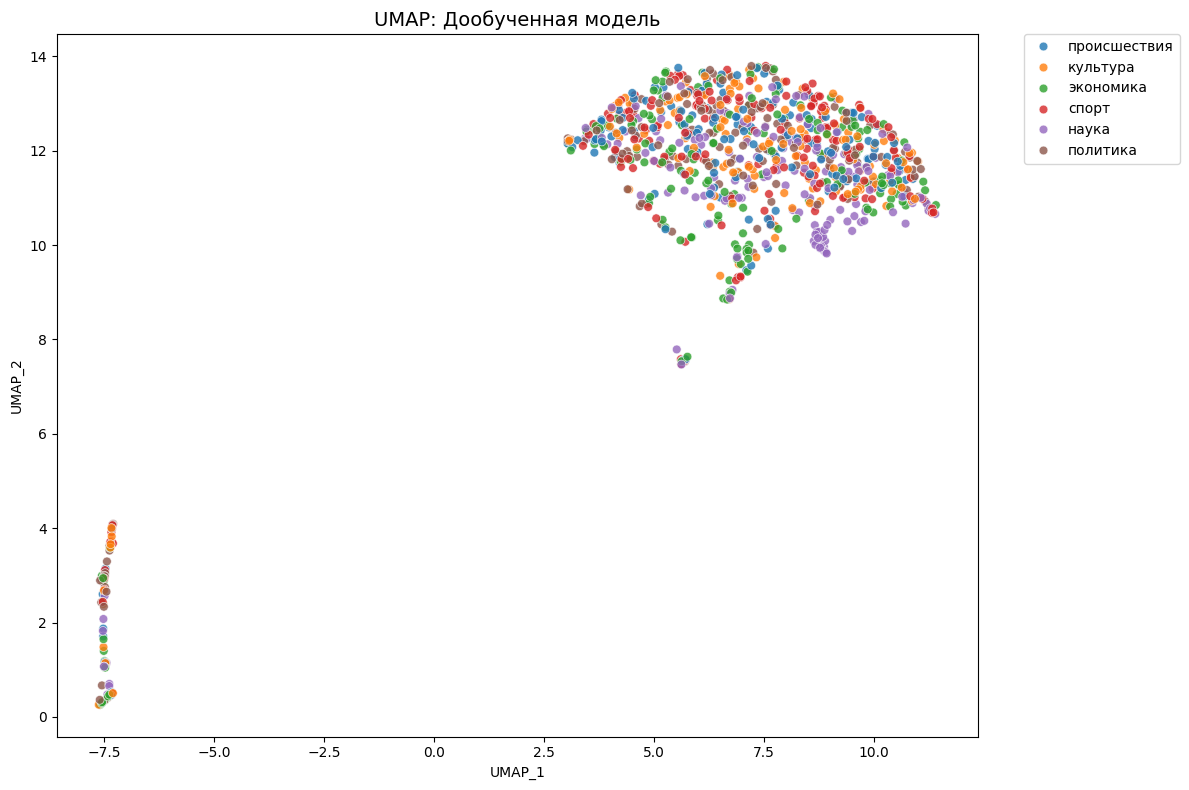

In [8]:
# Получение эмбеддингов дообученной моделью
with torch.no_grad():
    finetuned_embeddings = finetuned_model.encode(
        vis_texts,
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True
    )

# Визуализация
plot_embeddings(finetuned_embeddings, vis_labels, "UMAP: Дообученная модель")

### Выводы

Напишите краткий вывод по результатам эксперимента. Улучшились ли метрики? Как изменилась визуализация кластеров? Почему доменная адаптация на парафразах могла дать именно такой результат на задаче QA-поиска?

**Ваш ответ:**

1. Улучшились ли метрики?

Да, метрики Recall@5 и Recall@10 выросли, так как модель получила базовые знания русского языка и научилась сопоставлять смысловое сходство русскоязычных фраз.

2. Как изменилась визуализация кластеров?

Кластеры на графике UMAP стали более плотными и четко разделенными по тематикам, избавившись от хаотичного разброса точек, характерного для исходной англоязычной модели.

3. Почему доменная адаптация на парафразах дала именно такой результат для QA-поиска?

Обучение на парафразах помогло выстроить правильную геометрию русского языка, но не дало максимального буста в QA-поиске, так как задача поиска ответов требует сопоставления структуры «вопрос — ответ», а не просто поиска синонимичных утверждений.